<a href="https://colab.research.google.com/github/AIVIETNAM-AIO-HUYTRUONG/AIO/blob/keep-track/M3/ML-Base/Tree-based-Algorithms/balance_scale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 - Bộ dữ liệu **Balance Scale** gồm 625 samples và 4 features. Mỗi features nhận một giá trị từ `1` đến `5`.

| Tên cột | Ý nghĩa |
| :--- | :--- |
| `left_weight` | Khối lượng đặt ở phía trái |
| `left_distance` | Khoảng cách từ vật bên trái đến tâm cân |
| `right_weight` | Khối lượng đặt ở phía phải |
| `right_distance` | Khoảng cách từ vật bên phải đến tâm cân |
| `class_name` | Trạng thái L, B hoặc R |

---

| Lớp | Số mẫu | Tỷ lệ |
| :--- | :---: | :---: |
| L – lệch trái | 288 | 46,08% |
| B – cân bằng | 49 | 7,84% |
| R – lệch phải | 288 | 46,08% |
| **Tổng** | **625** | **100,00%** |

- Bộ dữ liệu **Balance Scale** được xác đinh bằng cách sử dụng công thức vậy lý **Mô-men lực Mô-men lực ($M$)** bằng phép nhân đơn giản:
    - $M_L = \text{left_weight} \times \text{left_distance}$ (Mô-men bên trái)  

    - $M_R = \text{right_weight} \times \text{right_distance}$ (Mô-men bên phải)  

- Quy tắc phân loại nhãn - Nếu:
    -  Khi $M_L > M_R$ (Cân nghiêng sang trái) $\Rightarrow$  **Nhãn L (Left)**
    -  Khi $M_L = M_R$ (Cân thăng bằng)  $\Rightarrow$  **Nhãn B (Balanced)**
    -  Khi $M_L < M_R$ (Cân nghiêng sang phải)  $\Rightarrow$  **Nhãn R (Right)**

- Lớp **B** hiếm hơn nhiều so với **L** và **R**. Vì vậy **accuracy** tổng thế có thể trông tương đối ổn định ngay cả khi mô hình nhận diện lớp **B** chưa tốt. Ta cần xem thêm **precision, recall, F1-score** theo từng lớp và **confusion matrix**.

# **1. Triển khai bằng Python**


## **1.1 Chuẩn bị môi trường**

- Cài đặt các thư viện cần thiết:
  - pandas: đọc dữ liệu
  - scikit-learn: để huấn luyện và đánh giá
  - matplotlib: để trực quan hóa

  ```text
  python-m pip install-U pandas matplotlib scikit-learn
  ```
- Nếu đang làm việc trên Google Colab hoặc một môi trường đã có sẵn các gói này, có thể bỏ qua bước cài đặt.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix)

## **1.2. Loading Data và Inspecting Data**

In [ ]:
DATA_URL = "https://archive.ics.uci.edu/static/public/12/data.csv"

COLUMNS = [
  "class_name",
  "left_weight",
  "left_distance",
  "right_weight",
  "right_distance"]

def load_data() -> pd.DataFrame:
  data = pd.read_csv(DATA_URL)

  if data.shape[1] != len(COLUMNS):
    raise ValueError(f"Expected {len(COLUMNS)} columns, got {data.shape[1]}")
  data.columns = COLUMNS
  return data

data = load_data()
print(f"Dataset shape: {data.shape}")
print(data)
print(data["class_name"].value_counts())


Dataset shape: (625, 5)
    class_name  left_weight  left_distance  right_weight  right_distance
0            B            1              1             1               1
1            R            1              1             1               2
2            R            1              1             1               3
3            R            1              1             1               4
4            R            1              1             1               5
..         ...          ...            ...           ...             ...
620          L            5              5             5               1
621          L            5              5             5               2
622          L            5              5             5               3
623          L            5              5             5               4
624          B            5              5             5               5

[625 rows x 5 columns]
class_name
R    288
L    288
B     49
Name: count, dtype: int64


- Kết quả cho thấy dữ liệu có 625 rows và 5 columns. Bước kiểm tra hình dạng này rất hữu ích khi nguồn dữ liệu trực tuyến thay đổi cấu trúc hoặc trả về nội dụng không mong đợi.

## **1.3. Chia tập huấn luyện và kiểm tra**


| Thuật ngữ tiếng Việt | Thuật ngữ tiếng Anh | Ý nghĩa / Giải thích trong Code |
| :--- | :--- | :--- |
| **Tập huấn luyện / Tập kiểm thử** | **Training set / Test set** | Tập dữ liệu dùng để cho mô hình học (Train) và tập dữ liệu độc lập dùng để đánh giá lại (Test). |
| **Khả năng tái lập** | **Reproducibility** | Đảm bảo mỗi lần chạy lại code đều cho ra cùng một kết quả chia dữ liệu (nhờ cố định `random_state`). |
| **Phân tầng dữ liệu** | **Stratified split (`stratify=y`)** | Kỹ thuật chia dữ liệu giữ nguyên tỷ lệ các lớp (nhất là lớp hiếm) cân bằng ở cả tập Train và Test. |
| **Lớp hiếm / Lớp yếu thế** | **Minority class / Imbalanced class** | Lớp chiếm tỷ lệ rất ít trong tập dữ liệu (ví dụ: lớp B chỉ chiếm khoảng 7.84% trong Balance Scale). |
| **Độ biến thiên** | **Variance** | Mức độ thay đổi của hiệu năng mô hình khi dữ liệu chia ngẫu nhiên theo các cách khác nhau. |
| **Kiểm tra chéo** | **Cross-validation (CV)** | Kỹ thuật chia dữ liệu thành $K$ phần (folds) để huấn luyện và đánh giá luân phiên, giúp kết quả đánh giá khách quan hơn. |

- Chúng ta sẽ dùng $70%$ data cho **traning set** và $30%$ cho **test set**, giữ `random_state = 100` để lần **run code** sau có thể **reproduce** cùng một **split**.

In [ ]:
FEATURES = [
    "left_weight",
    "left_distance",
    "right_weight",
    "right_distance",
]

X = data[FEATURES]
y = data["class_name"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=100,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (437, 4)
y_train shape: (437,)
X_test shape: (188, 4)
y_test shape: (188,)


## **1.4.  Huấn luyện cây với Gini và Entropy**

| Thuật ngữ tiếng Việt | Thuật ngữ tiếng Anh | Ý nghĩa / Giải thích trong Code |
| :--- | :--- | :--- |
| **Tiêu chí phân chia** | **Splitting criterion** | Thước đo dùng để đánh giá chất lượng rẽ nhánh (chọn `criterion='gini'` hoặc `criterion='entropy'`). |
| **Cây nông** | **Shallow tree** | Cây có độ sâu nhỏ (`max_depth` thấp), giúp mô hình đơn giản, dễ đọc và tránh overfitting. |
| **Dễ quan sát / Giải thích** | **Interpretable / Explainable** | Khả năng con người có thể hiểu và diễn giải được logic đưa ra quyết định của mô hình. |
| **Học thuộc dữ liệu** | **Overfitting / Memorization** | Hiện tượng mô hình ghi nhớ chi tiết nhiễu của tập huấn luyện thay vì học quy luật tổng quát. |
| **Giá trị tối ưu** | **Optimal value** | Bộ siêu tham số mang lại hiệu năng tốt nhất sau khi tinh chỉnh (Hyperparameter tuning). |


- Hai mô hình dùng cùng độ sâu (**max_depth**) và kích thước nút lá (**min_samples_leaf**). Như vậy, khác biệt chính giữa chúng nằm ở tiêu chí phân chia (**splitting criterion**).

In [ ]:
def train_models(X_train: pd.DataFrame, y_train:pd.DataFrame):
  common_params = {
      "max_depth": 3,
      "min_samples_leaf": 5,
      "random_state": 100
  }

  models = {}
  for criterion in ["gini", "entropy"]:
    model = DecisionTreeClassifier(
        criterion=criterion,
         **common_params
    )
    model.fit(X_train, y_train)
    models[criterion] = model
  return models

models = train_models(X_train, y_train)
models

{'gini': DecisionTreeClassifier(max_depth=3, min_samples_leaf=5, random_state=100),
 'entropy': DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=5,
                        random_state=100)}

- Giới hạn `max_depth=3` khiến cây khá nông (**shallow tree**). Đây là một lựa chọn có chủ đích để cây dễ quan sát, trực quan hóa (**interpretable**) và giảm nguy cơ quá khớp (**overfitting**), không phải **optimal value** cho mọi bài toán.

## **1.5. Đánh giá mô hình**


| Thuật ngữ tiếng Việt | Thuật ngữ tiếng Anh | Ý nghĩa / Giải thích trong Code |
| :--- | :--- | :--- |
| **Độ chính xác** | **Accuracy** | Tỷ lệ tổng số mẫu được đoán đúng trên toàn bộ tập dữ liệu. |
| **Ma trận nhầm lẫn** | **Confusion matrix** | Bảng so sánh giữa nhãn thực tế (Actual) và nhãn dự đoán (Predicted) để xem mô hình hay bị nhầm lớp nào. |
| **Báo cáo phân loại** | **Classification report** | Bảng thống kê chi tiết các chỉ số Precision, Recall, F1-score và Support cho từng lớp. |
| **Độ xác thực** | **Precision** | Trong số các mẫu mô hình đoán là lớp X, có bao nhiêu phần trăm thực sự là lớp X. |
| **Độ gợi nhớ** | **Recall** | Trong số tất cả các mẫu thực sự là lớp X, mô hình đã tìm ra được bao nhiêu phần trăm. |
| **Điểm F1** | **F1-score** | Trung bình hài hòa (harmonic mean) giữa Precision và Recall, giúp đánh giá cân bằng mô hình. |
| **Thứ tự nhãn** | **Label order (`model.classes_`)** | Thuộc tính của mô hình lưu trữ thứ tự các lớp (ví dụ: `['B', 'L', 'R']`), dùng để định vị hàng/cột trong Confusion Matrix. |

- "**Accuracy** trả lời câu hỏi “mô hình đoán đúng bao nhiêu phần trăm **samples**". **Confusion matrix** cho biết lỗi xảy ra giữa những **classes** nào, còn **classfication report** tách **precision**, **recall** và **F1-score** theo từng **class**.

In [ ]:
def evaluate_model(
    name:str,
    model:DecisionTreeClassifier,
    X_test:pd.DataFrame,
    y_test:pd.DataFrame
  ):
  y_pred = model.predict(X_test)

  accuracy = accuracy_score(y_test, y_pred)
  confusion = confusion_matrix(y_test, y_pred)
  report = classification_report(y_test, y_pred)
  print(f"\n==== {name} ====")
  print("Confusion matrix:")
  print(confusion)
  print("Classification report:")
  print(report)
  print("Accuracy:", accuracy)
  pass

predictions = {}

for name, model in models.items():
  predictions[name] = evaluate_model(
      name,
      model,
      X_test,
      y_test
  )



==== gini ====
Confusion matrix:
[[ 0  8  7]
 [ 0 67 20]
 [ 0 17 69]]
Classification report:
              precision    recall  f1-score   support

           B       0.00      0.00      0.00        15
           L       0.73      0.77      0.75        87
           R       0.72      0.80      0.76        86

    accuracy                           0.72       188
   macro avg       0.48      0.52      0.50       188
weighted avg       0.67      0.72      0.69       188

Accuracy: 0.723404255319149

==== entropy ====
Confusion matrix:
[[ 0  8  7]
 [ 0 67 20]
 [ 0 17 69]]
Classification report:
              precision    recall  f1-score   support

           B       0.00      0.00      0.00        15
           L       0.73      0.77      0.75        87
           R       0.72      0.80      0.76        86

    accuracy                           0.72       188
   macro avg       0.48      0.52      0.50       188
weighted avg       0.67      0.72      0.69       188

Accuracy: 0.7234042

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/m

- Khi đọc **confusion matrix**, cần kiểm tra đúng **label order (thứ tự nhãn)**. Trong code trên, thứ tự được lấy tự động từ `model.classes_` thay vì hard-code, nhờ đó tránh gán nhầm row hoặc column.

## **1.6. Trực quan hóa**

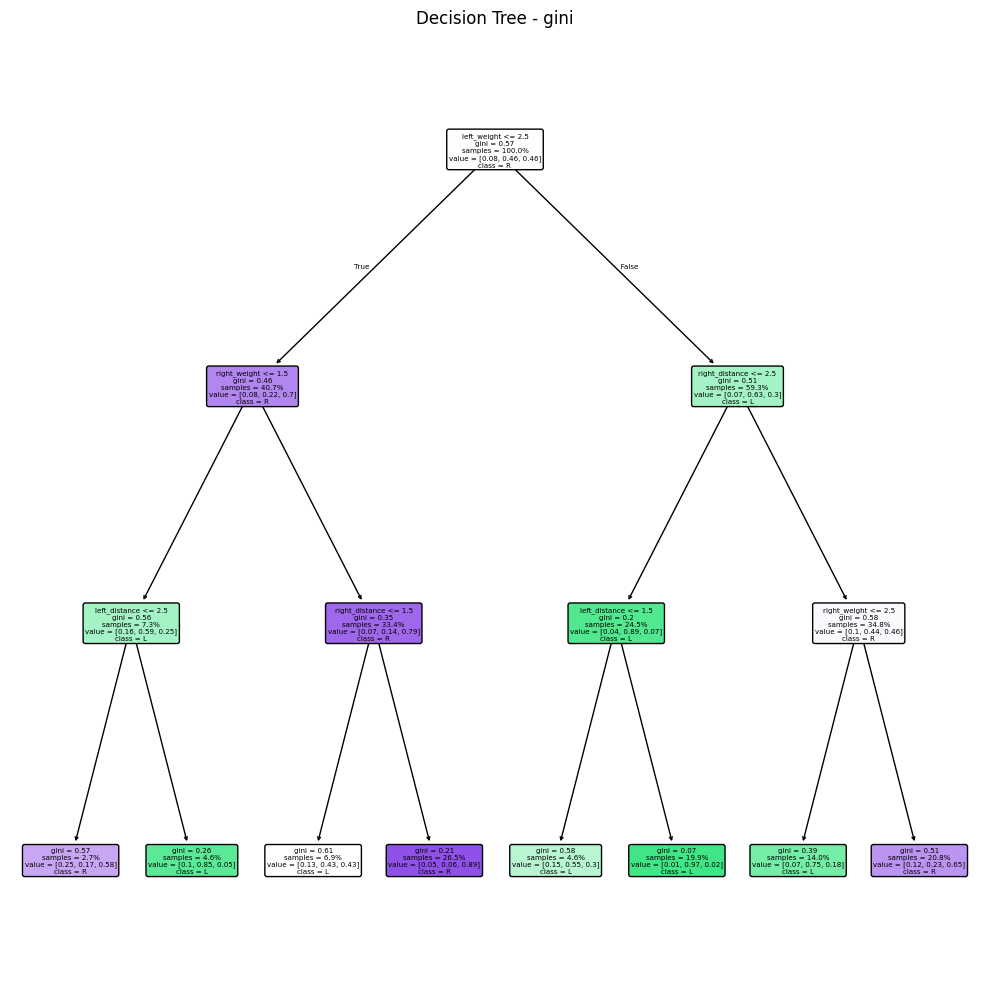

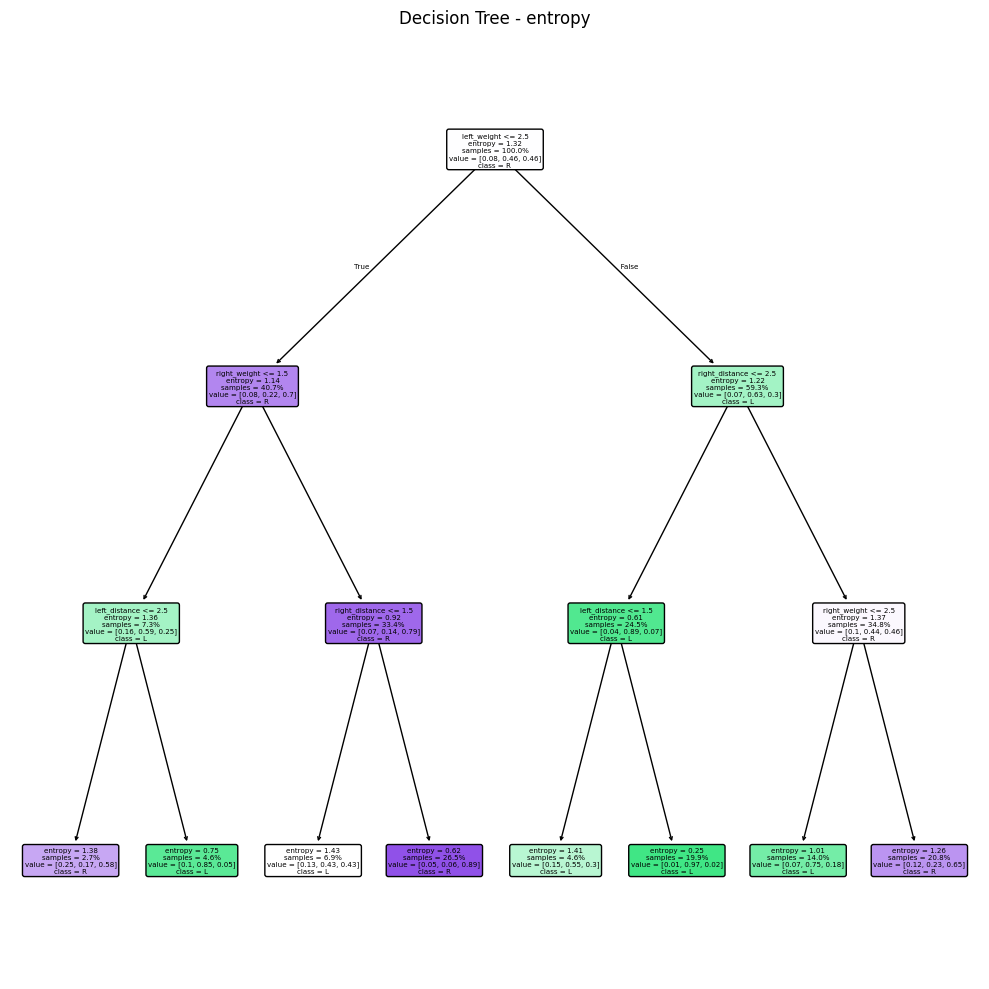

In [ ]:
def show_tree(name, model):
  plt.figure(figsize=(10, 10))
  plot_tree(
      model,
      feature_names=FEATURES,
      class_names=model.classes_.astype(str),
      filled=True,
      rounded=True,
      proportion=True,
      precision=2,
  )
  plt.title(f"Decision Tree - {name}")
  plt.tight_layout()
  plt.show()

for name, model in models.items():
  show_tree(name, model)